In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/household_energy_consumption - household_energy_consumption.csv")

In [3]:
df.shape

(28107, 7)

In [4]:
df.head()

,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4.0,17.8,No,3.2
1,H00001,2025-04-02,7.9,4.0,17.3,No,2.8
2,H00001,2025-04-03,9.2,4.0,18.6,No,3.0
3,H00001,2025-04-04,7.9,4.0,18.2,No,2.7
4,H00001,2025-04-05,9.6,4.0,11.9,No,3.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28107 entries, 0 to 28106
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            28107 non-null  object 
 1   Date                    28107 non-null  object 
 2   Energy_Consumption_kWh  28107 non-null  float64
 3   Household_Size          28106 non-null  float64
 4   Avg_Temperature_C       28106 non-null  float64
 5   Has_AC                  28106 non-null  object 
 6   Peak_Hours_Usage_kWh    28106 non-null  float64
dtypes: float64(4), object(3)
memory usage: 1.5+ MB


In [6]:
df.describe()

,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Peak_Hours_Usage_kWh
count,28107.000000,28106.000000,28106.000000,28106.000000
mean,10.652635,3.507080,17.519807,4.350914
std,5.509173,1.711552,2.503817,2.524881
min,0.500000,1.000000,10.000000,0.200000
25%,6.000000,2.000000,15.800000,2.300000
50%,10.500000,4.000000,17.500000,4.000000
75%,14.900000,5.000000,19.200000,6.000000
max,20.000000,6.000000,25.000000,10.000000


In [7]:
df.isnull().sum()


,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,1
Avg_Temperature_C,1
Has_AC,1
Peak_Hours_Usage_kWh,1


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

In [9]:
df.columns

Index(['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size',
       'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh'],
      dtype='object')

In [10]:
df=df.dropna()

In [11]:
x=df[[
    "Household_Size",
    "Avg_Temperature_C",
    "Peak_Hours_Usage_kWh"
]]

y= df["Energy_Consumption_kWh"]

In [12]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
poly= PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [14]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

LinearRegression()

In [15]:
y_pred=model.predict(x_test_poly)

In [16]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)

In [18]:
print("\n Polynomial Regression Results")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("RS:",r2)


 Polynomial Regression Results
MAE: 0.5763488616351677
MSE: 0.5393017113657234
RMSE: 0.7343716439009089
RS: 0.9817288549891474


In [20]:
r=pd.DataFrame({
    "Actual Energy":y_test.values,
    "Predicted Energy":y_pred
})
print("\n Actual vs Predicted Energy Consumption")
print(r.head(10))


 Actual vs Predicted Energy Consumption
   Actual Energy  Predicted Energy
0            7.2          7.255380
1           18.4         18.450477
2           11.3         11.432529
3           12.5         12.519690
4           20.0         20.898071
5           15.9         15.173400
6            2.7          2.739847
7           16.9         18.074506
8            2.5          2.783465
9            8.7          9.126361


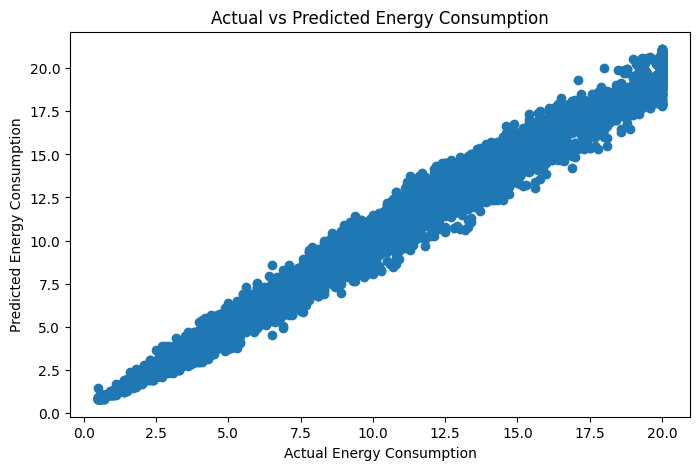

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()